In [33]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 

In [34]:
vid = cv2.VideoCapture('video/mouse_1.avi') 

In [35]:
#Создание массива всего видео в виде кадров
check, img = vid.read()
frames = []
if check:
    i = 1
    while(check):
        check, img = vid.read()
        if(check):
            img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            frames.append(img_grey)
vid.release()
print(f"Загружено {len(frames)} кадров")

Загружено 6075 кадров


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

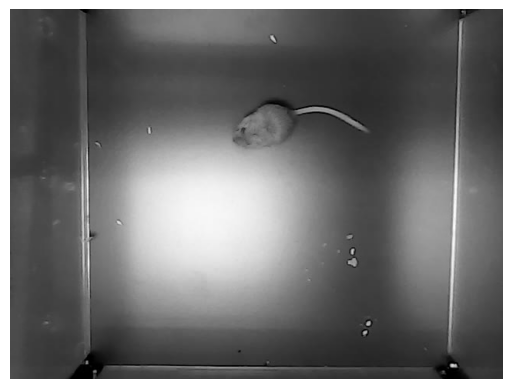

In [216]:
img_0 = cv2.cvtColor(frames[1990], cv2.COLOR_BGR2RGB)
plt.imshow(img_0)
plt.axis('off')

In [ ]:
frames
h, w  = frames[0].shape
plt.imshow(frames[122], cmap='gray')

In [43]:
#Выделение медианного значения для каждого пикселя (наиболее общего кадра) из массива
def median_image (frames):
    quan = len(frames)
    h, w  = frames[0].shape
    newimg = np.zeros((h,w),dtype=frames[0].dtype)
    for j in range (h):
        for k in range (w):
            hist = np.zeros(256, dtype=np.uint32)
            for i in range (quan):
                hist[frames[i][j][k]] += 1
            newimg[j][k] = np.argmax(hist)
    return newimg

True

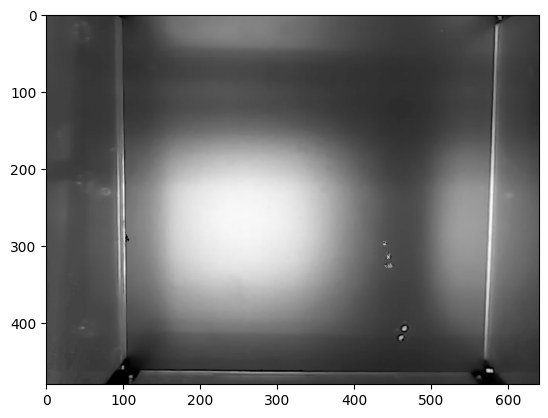

In [ ]:
mid_img = median_image(frames) 
plt.imshow(mid_img, cmap='gray')
cv2.imwrite('mig_img.jpg', mid_img)

In [241]:
def get_mouse(diff_image):  
    _,thresh = cv2.threshold(diff_image.copy(), 45, 255,cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, np.ones((5, 5), np.uint8), iterations=2)
    thresh = cv2.dilate(thresh, np.ones((9, 9), np.uint8), iterations=2)
    return thresh

In [ ]:
img1 = frames[4033].copy()
img_median = cv2.imread('video/mig_img.jpg')
img_median = cv2.cvtColor(img_median, cv2.COLOR_BGR2GRAY)

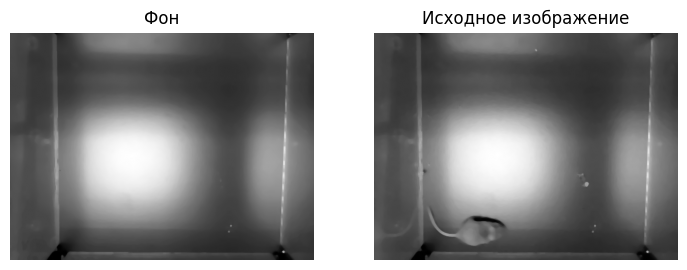

In [ ]:
med_equl1 = cv2.medianBlur(img_median.copy(), 7)
med_equl2 = cv2.medianBlur(img1.copy(), 7)

plt.figure(figsize=(18, 10))

plt.subplot(2, 4, 1)
plt.imshow(med_equl1, cmap='gray')
plt.title("Фон")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(med_equl2, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')

plt.show()

In [222]:
equalized1 = cv2.equalizeHist(med_equl1.copy())
equalized2 = cv2.equalizeHist(med_equl2.copy())

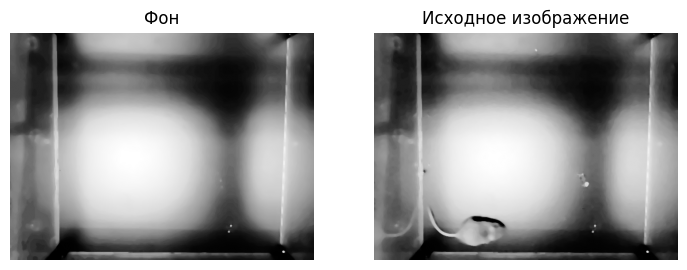

In [223]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 4, 1)
plt.imshow(equalized1, cmap='gray')
plt.title("Фон")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(equalized2, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')

plt.show()

In [185]:
def addWeighted(image1, image2):
    diff = image2.astype(np.int16) - image1.astype(np.int16)
    # Берём абсолютное значение
    abs_diff = np.abs(diff)
    # Приводим обратно к uint8 (обрезаем значения >255)
    return np.clip(abs_diff, 0, 255).astype(np.uint8)

In [303]:
diff_image = addWeighted(equalized2.copy(),equalized1.copy())

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

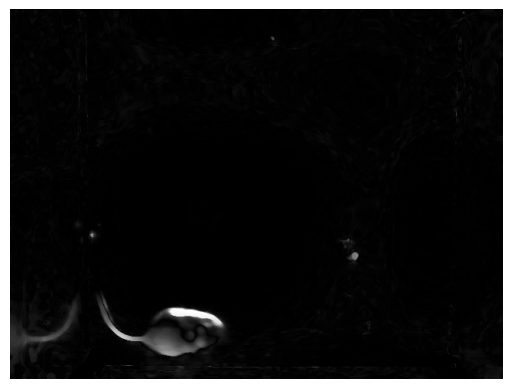

In [304]:
plt.imshow(diff_image, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

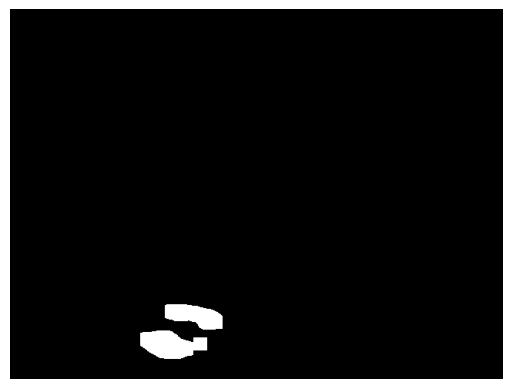

In [242]:
mouse = get_mouse(diff_image)
plt.imshow(mouse, cmap='gray')
plt.axis('off')

In [117]:
def mod_fon (arr_image, img_median):
    mod_fon = np.zeros(arr_image[0].shape, dtype='uint8')
    mom=[None]*len(arr_image)
    for k in range(len(arr_image)):
        n = 7
        med_equl1 = cv2.medianBlur(img_median.copy(), n)
        med_equl2 = cv2.medianBlur(arr_image[k].copy(), n)
        equalized1 = cv2.equalizeHist(med_equl1.copy())
        equalized2 = cv2.equalizeHist(med_equl2.copy())
        med_equl1 = equalized1
        med_equl2 = equalized2
        diff_image1 =cv2.addWeighted(med_equl1.copy(),1,med_equl2.copy(),-1, 0)
        diff_image2 =cv2.addWeighted(med_equl2.copy(),1,med_equl1.copy(),-1, 0)
        diff_image = cv2.addWeighted(diff_image2,1,diff_image1,1, -30)
        mouse = get_mouse(diff_image)
        mu=cv2.moments(mouse)
        mom[k]=(mu['m10'] / (mu['m00'] + 1e-2), mu['m01'] / (mu['m00'] + 1e-2))
        if(mom[k][0]==0 and mom[k][1]==0):
            mom[k]=mom[k-1]
    return mom

In [118]:
data=mod_fon(frames, img_median)

In [57]:
# Здесь будут храниться X-координаты центра масс для каждого кадра.
D1=[None]*len(data)
#Здесь будут храниться Y-координаты центра масс для каждого кадра.
D2=[None]*len(data)
for k in range(len(data)):
  D1[k] = data[k][0]
  D2[k] = data[k][1]

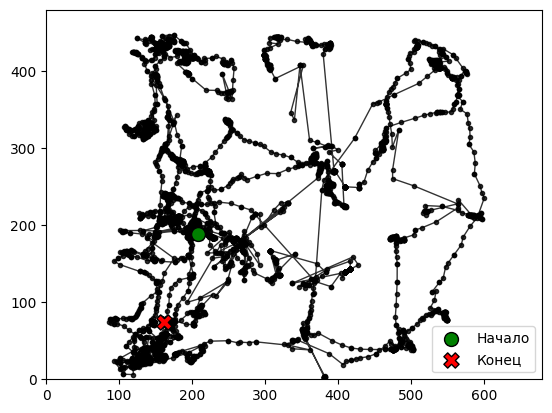

In [299]:


plt.xlim(0, 680) 
plt.ylim(0, 480) 
plt.plot(D1, D2, color='black', marker='.', linewidth=1, alpha=0.8)

# Стартовая точка (первый кадр)
plt.scatter(D1[0], D2[0], color='green', s=100, edgecolors='black', 
            zorder=5, label='Начало')

# Конечная точка (последний кадр)
plt.scatter(D1[-1], D2[-1], color='red', s=120, marker='X', 
            edgecolors='black', zorder=5, label='Конец')
plt.legend()
plt.show()